In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\Lala\Downloads\archive\data.csv", encoding='latin-1')

In [3]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [4]:
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

In [5]:
df.shape

(541909, 8)

In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
cancelled_orders = df[df["InvoiceNo"].astype(str).str.startswith("C")]


In [8]:
cancelled_orders.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom


In [13]:
df= df.dropna(subset=["CustomerID"])

In [14]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [15]:
df= df[df['Quantity']>0]

In [16]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [17]:
df['Revenue']=df["Quantity"] * df["UnitPrice"]

C:\Users\Lala\AppData\Local\Temp\ipykernel_19344\3334248611.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Revenue']=df["Quantity"] * df["UnitPrice"]


In [18]:
df['Revenue']

0         15.30
1         20.34
2         22.00
3         20.34
4         20.34
          ...  
541904    10.20
541905    12.60
541906    16.60
541907    16.60
541908    14.85
Name: Revenue, Length: 397924, dtype: float64

In [19]:
customer_summary = df.groupby("CustomerID").agg(
    Total_Revenue=("Revenue","sum"),
    Total_Orders=("InvoiceNo","nunique"),
    Avg_Order_Value=("Revenue","mean"))


In [20]:
customer_summary

,Total_Revenue,Total_Orders,Avg_Order_Value
CustomerID,,,
12346.0,77183.60,1,77183.600000
12347.0,4310.00,7,23.681319
12348.0,1797.24,4,57.975484
12349.0,1757.55,1,24.076027
12350.0,334.40,1,19.670588
...,...,...,...
18280.0,180.60,1,18.060000
18281.0,80.82,1,11.545714
18282.0,178.05,2,14.837500


In [22]:
country_summary = df.groupby("Country").agg(
    Total_Revenue=("Revenue","sum"),
    Order_Count=("InvoiceNo","nunique"))

country_summary["Revenue_Share (%)"] = (
    country_summary["Total_Revenue"]
    / country_summary["Total_Revenue"].sum()) * 100

country_summary.sort_values(by="Total_Revenue",ascending=False)

,Total_Revenue,Order_Count,Revenue_Share (%)
Country,,,
United Kingdom,7308391.554,16649,82.011638
Netherlands,285446.340,95,3.203156
EIRE,265545.900,260,2.979842
Germany,228867.140,457,2.568249
France,209024.050,389,2.345578
Australia,138521.310,57,1.554427
Spain,61577.110,90,0.690992
Switzerland,56443.950,51,0.633390
Belgium,41196.340,98,0.462288


In [23]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["Month"] = df["InvoiceDate"].dt.to_period("M")

monthly_revenue = df.groupby("Month")["Revenue"].sum()

monthly_revenue

C:\Users\Lala\AppData\Local\Temp\ipykernel_19344\3930476202.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
C:\Users\Lala\AppData\Local\Temp\ipykernel_19344\3930476202.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Month"] = df["InvoiceDate"].dt.to_period("M")


Month
2010-12     572713.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518192.790
Freq: M, Name: Revenue, dtype: float64

# TREND LINE

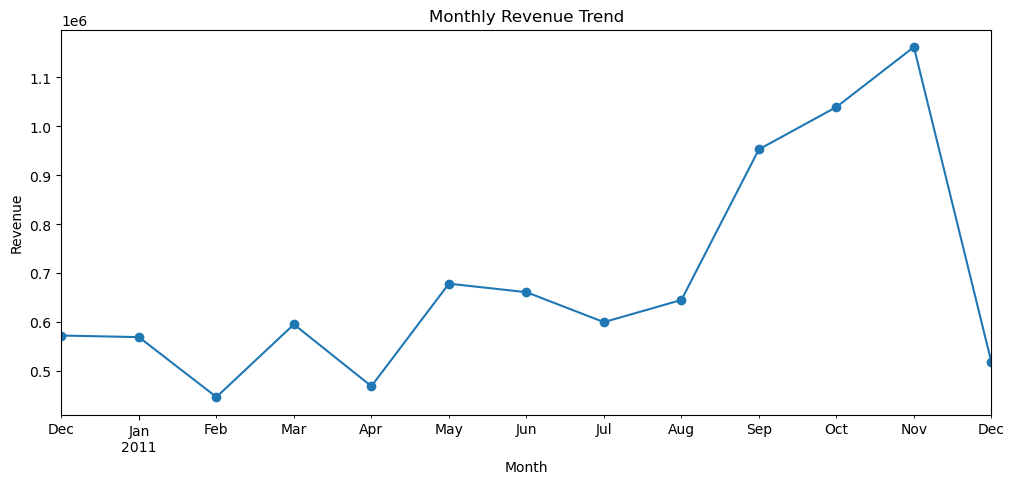

In [24]:
monthly_revenue.plot(marker="o", figsize=(12,5))
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

### Aylıq gəlirlər il ərzində sabit olmayıb və bəzi aylarda nəzərəçarpacaq artım müşahidə olunur.
### Ən yüksək gəlir əldə olunan aylar satışların pik dövrünü göstərir və bu, mövsümi tələbat və ya kampaniyalarla əlaqəli ola bilər.

In [25]:
top_products = (df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(20))


In [26]:
top_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
PACK OF 12 LONDON TISSUES             25345
PACK OF 60 PINK PAISLEY CAKE CASES    24264
BROCADE RING PURSE                    22963
VICTORIAN GLASS HANGING T-LIGHT       22433
ASSORTED COLOURS SILK FAN             21876
RED  HARMONICA IN BOX                 20975
JUMBO BAG PINK POLKADOT               20165
SMALL POPCORN HOLDER                  18252
LUNCH BAG RED RETROSPOT               17697
60 TEATIME FAIRY CAKE CASES           17689
Name: Quantity, dtype: int64

In [27]:
total_orders = df.groupby("Country")["InvoiceNo"].nunique()

cancelled_country = (cancelled_orders.groupby("Country")["InvoiceNo"].nunique())

return_rate = ( cancelled_country / total_orders) * 100

return_rate.fillna(0)

Country
Australia                21.052632
Austria                  11.764706
Bahrain                  50.000000
Belgium                  21.428571
Brazil                    0.000000
Canada                    0.000000
Channel Islands          26.923077
Cyprus                   25.000000
Czech Republic          150.000000
Denmark                  16.666667
EIRE                     27.692308
European Community       25.000000
Finland                  17.073171
France                   17.737789
Germany                  31.947484
Greece                   20.000000
Hong Kong                 0.000000
Iceland                   0.000000
Israel                   20.000000
Italy                    44.736842
Japan                    47.368421
Lebanon                   0.000000
Lithuania                 0.000000
Malta                   100.000000
Netherlands               6.315789
Norway                   11.111111
Poland                   26.315789
Portugal                 22.807018
RSA         

# VIZUALIZATION 1

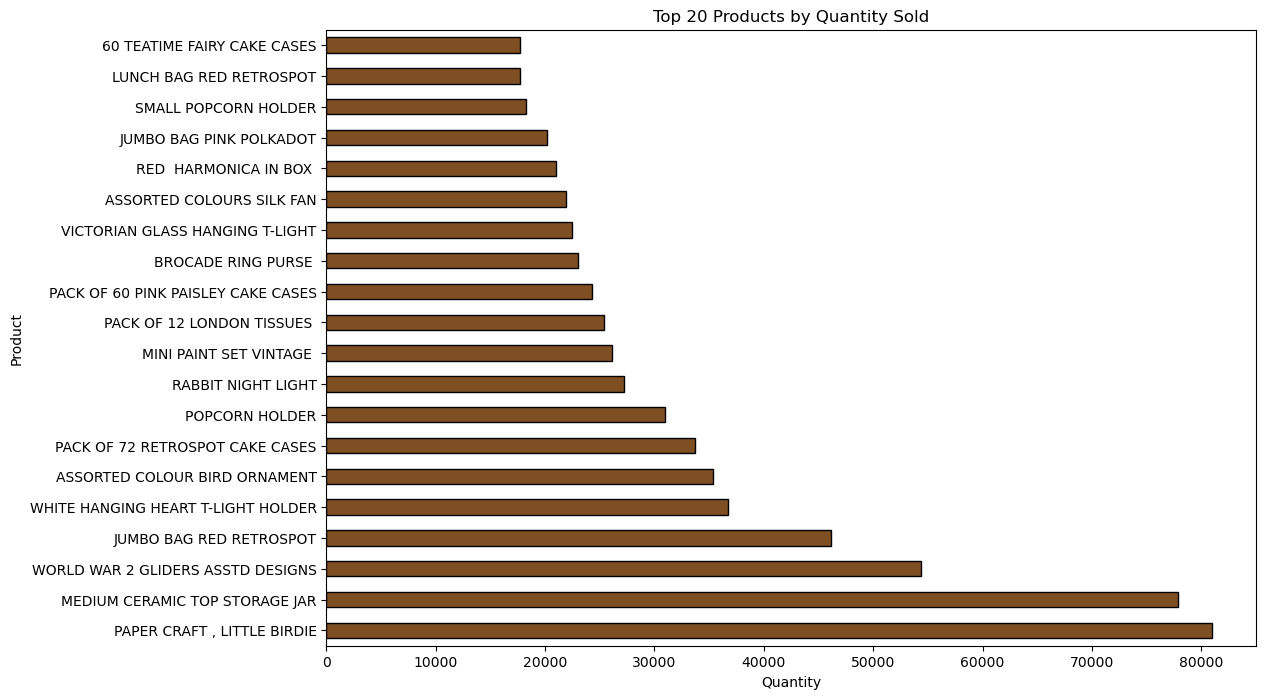

In [29]:
top_products.plot.barh(figsize=(12,8),color='#7f4f24',edgecolor='black')
plt.title("Top 20 Products by Quantity Sold")
plt.xlabel("Quantity")
plt.ylabel("Product")

plt.show()

# VIZUALIZATION 2

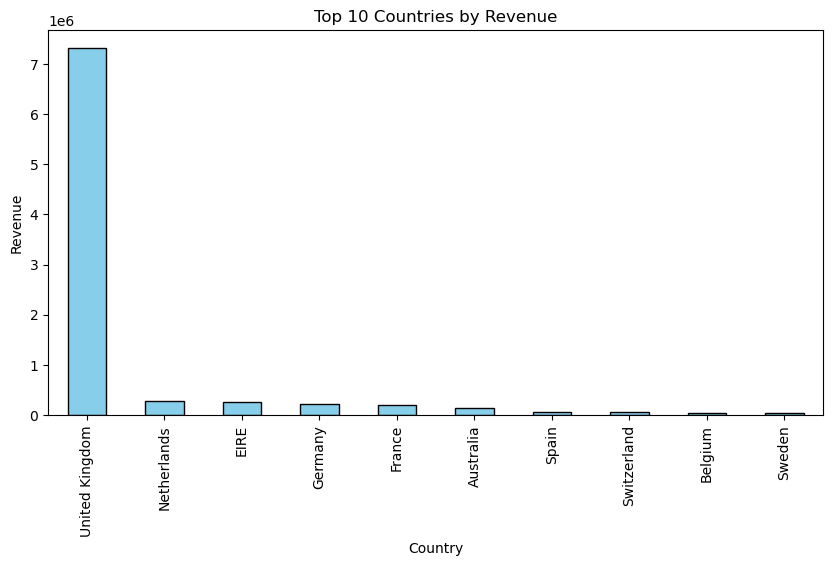

In [32]:
country_summary.sort_values( by="Total_Revenue",ascending=False).head(10)["Total_Revenue"].plot.bar(figsize=(10,5),color ='skyblue',edgecolor='black')
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.show()

# VIZUALIZATION 3

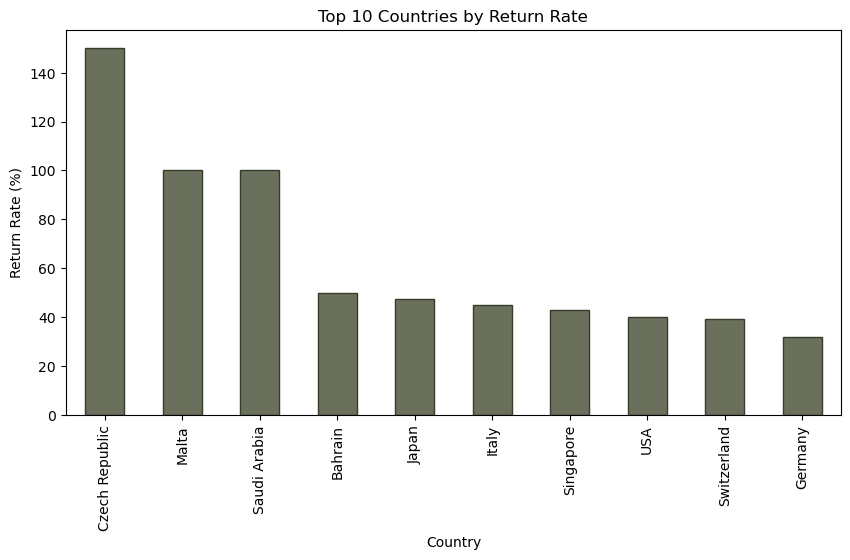

In [34]:
return_rate.sort_values( ascending=False).head(10).plot.bar(figsize=(10,5),color='#6b705c', edgecolor='#333d29')
plt.title("Top 10 Countries by Return Rate")
plt.xlabel("Country")
plt.ylabel("Return Rate (%)")

plt.show()

# BONUS 1

In [35]:
top10_customers = (df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False).head(10))

top10_customers

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: Revenue, dtype: float64

## Monthly Spending Trend of Top 10 Customers

In [37]:
top_customer_trend = (df[df["CustomerID"].isin(top10_customers.index)].groupby([df["InvoiceDate"].dt.to_period("M"),"CustomerID"] )["Revenue"] 
    .sum().unstack())

top_customer_trend

CustomerID,12346.0,12415.0,14156.0,14646.0,14911.0,16029.0,16446.0,17450.0,17511.0,18102.0
InvoiceDate,,,,,,,,,,
2010-12,NaN,NaN,322.20,8591.88,7737.94,13112.52,NaN,2028.84,6711.08,27834.61
2011-01,77183.6,7092.98,16774.72,26476.68,5129.47,2139.39,NaN,18620.20,3862.14,NaN
2011-02,NaN,14022.92,8655.33,22797.46,1471.19,4200.36,NaN,NaN,7783.64,10535.48
2011-03,NaN,16726.84,9744.62,21462.40,10452.18,3487.08,NaN,13500.50,7238.58,6909.32
2011-04,NaN,350.00,2998.18,2976.56,4572.32,1340.40,NaN,3585.04,2941.80,1196.96
2011-05,NaN,12691.16,5412.18,28408.14,9436.68,11496.51,2.9,18025.68,7213.16,18165.74
2011-06,NaN,23426.81,9757.79,25288.99,10078.20,3969.60,NaN,5405.48,4415.44,41959.44
2011-07,NaN,2955.01,26464.99,26.02,13463.58,2170.08,NaN,8485.14,7590.01,22949.76
2011-08,NaN,21880.44,4871.89,40327.81,12095.49,10471.30,NaN,16119.46,8419.62,985.92


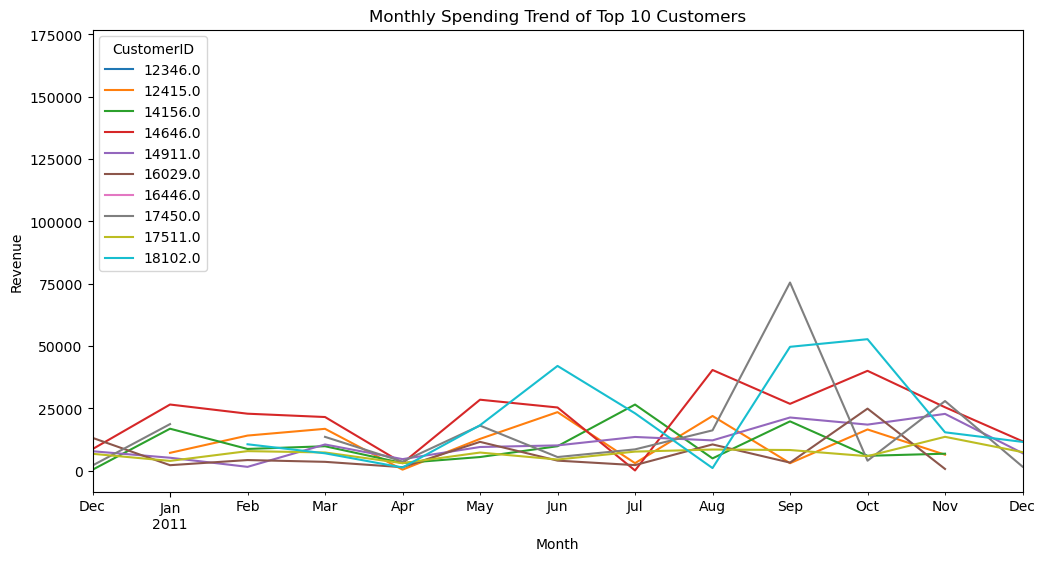

In [38]:
top_customer_trend.plot(figsize=(12,6))

plt.title("Monthly Spending Trend of Top 10 Customers")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

### Top 10 müştərinin aylıq xərclərində fərqli alış davranışları müşahidə olunur. Bəzi müştərilər demək olar ki, hər ay alış-veriş etdiyi halda, bəziləri yalnız müəyyən aylarda yüksək məbləğdə alış edib.

# BONUS 2

In [39]:
basket_size = (df.groupby(["Country","InvoiceNo"])["Description"] .nunique().groupby("Country") .mean().sort_values(ascending=False))

basket_size

Country
RSA                     58.000000
Israel                  48.800000
Lebanon                 45.000000
Cyprus                  37.375000
Switzerland             36.098039
USA                     35.800000
Brazil                  32.000000
Singapore               31.142857
Unspecified             29.875000
Norway                  29.694444
Greece                  29.000000
Channel Islands         28.730769
EIRE                    27.792308
Spain                   27.377778
Iceland                 26.000000
Portugal                25.228070
Canada                  25.000000
Netherlands             24.873684
Austria                 23.411765
United Arab Emirates    22.666667
Malta                   22.400000
France                  21.352185
Denmark                 21.000000
Australia               20.736842
Belgium                 20.693878
United Kingdom          20.683645
Italy                   19.947368
Germany                 19.726477
Poland                  17.368421
Japan 

# Business Insights